Boudah Mohamed Lemine C20121

#  PROJET D'EXAMEN Optimisation  

## Exercice 2: Stochasticité et Passage à l’Échelle

### Importation des données 

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

#Importation des données 
df = pd.read_csv("YearPredictionMSD.csv", header=None)

# Séparer features et target
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Standardisation des features 
scaler = StandardScaler()
X = scaler.fit_transform(X)




In [8]:
print("Any NaN in X?", np.isnan(X).any())
print("Any NaN in y?", np.isnan(y).any())
print("X min/max:", X.min(), X.max())
print("y min/max:", y.min(), y.max())


Any NaN in X? False
Any NaN in y? False
X min/max: -66.87402754080193 62.03765704925929
y min/max: -381.42443 677.89963


### a) Implémentation SGD

In [13]:
def sgd(X, y, w_init, lr=0.001, n_epochs=5, mu=0.01):
    """
    Descente de Gradient Stochastique from scratch
    """
    n_samples, n_features = X.shape
    w = w_init.copy()
    losses = []

    for epoch in range(n_epochs):
        indices = np.random.permutation(n_samples)
        for i in indices:
            xi = X[i]
            yi = y[i]
            grad = (xi @ w - yi) * xi + mu * w   
            w -= lr * grad                    
        # Loss لكل epoch
        loss = np.mean((X @ w - y)**2)/2 + mu/2 * np.sum(w**2)
        losses.append(loss)
        print(f"Epoch {epoch+1}, Loss={loss:.4f}")
    return w, losses


In [14]:
w_init = np.zeros(X.shape[1])
w_sgd, losses_sgd = sgd(X, y, w_init, lr=0.0001, n_epochs=5, mu=0.01)

# Affichage du loss final
print("Loss final SGD:", losses_sgd[-1])

Epoch 1, Loss=163.9851
Epoch 2, Loss=163.5671
Epoch 3, Loss=164.1935
Epoch 4, Loss=164.3318
Epoch 5, Loss=163.3861
Loss final SGD: 163.38612406814528


### b) Analyse Comparative

In [15]:
import time
import matplotlib.pyplot as plt

def batch_gradient(X, y, w_init, lr=0.001, n_epochs=5, mu=0.01):
    n_samples, n_features = X.shape
    w = w_init.copy()
    losses = []
    times = []

    for epoch in range(n_epochs):
        start = time.time()
        grad = X.T @ (X @ w - y) / n_samples + mu * w
        w -= lr * grad
        loss = np.mean((X @ w - y)**2)/2 + mu/2 * np.sum(w**2)
        losses.append(loss)
        times.append(time.time() - start)
        print(f"Batch Epoch {epoch+1}, Loss={loss:.4f}, Time={times[-1]:.4f}s")
    return w, losses, times



In [17]:
X_batch = X[:10000]
y_batch = y[:10000]

w_init = np.zeros(X.shape[1])

w_batch, losses_batch, times_batch = batch_gradient(X_batch, y_batch, w_init, lr=0.001, n_epochs=5, mu=0.01)


Batch Epoch 1, Loss=251.9048, Time=0.0041s
Batch Epoch 2, Loss=251.4622, Time=0.0030s
Batch Epoch 3, Loss=251.0245, Time=0.0020s
Batch Epoch 4, Loss=250.5916, Time=0.0030s
Batch Epoch 5, Loss=250.1636, Time=0.0020s


In [18]:
X_sgd = X[:10000]
y_sgd = y[:10000]

w_sgd, losses_sgd = sgd(X_sgd, y_sgd, w_init, lr=0.001, n_epochs=5, mu=0.01)


Epoch 1, Loss=172.9235
Epoch 2, Loss=175.4858
Epoch 3, Loss=175.6627
Epoch 4, Loss=188.3858
Epoch 5, Loss=171.3523


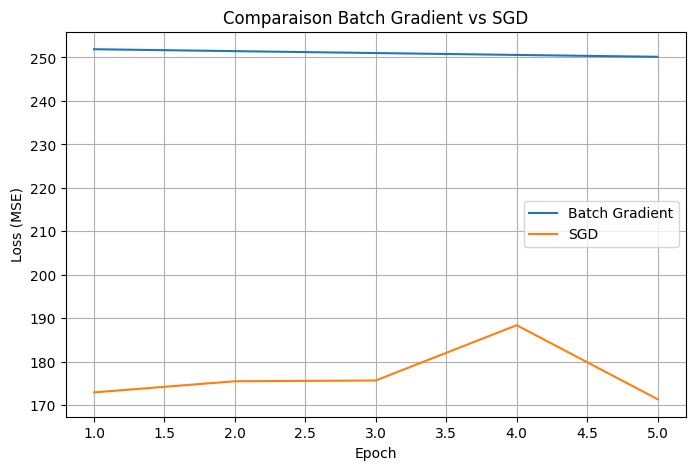

In [20]:
plt.figure(figsize=(8,5))
plt.plot(range(1,6), losses_batch, label='Batch Gradient')
plt.plot(range(1,6), losses_sgd, label='SGD')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Comparaison Batch Gradient vs SGD')
plt.legend()
plt.grid(True)
#plt.savefig("MSE_comparaison.png", dpi=300)
plt.show()


### c) Mini-batch et Adam

In [21]:
def minibatch_sgd(X, y, w_init, lr=0.001, n_epochs=5, batch_size=64, mu=0.01):
    n_samples, n_features = X.shape
    w = w_init.copy()
    losses = []

    for epoch in range(n_epochs):
        indices = np.random.permutation(n_samples)
        for start in range(0, n_samples, batch_size):
            batch_idx = indices[start:start + batch_size]
            X_batch = X[batch_idx]
            y_batch = y[batch_idx]
            grad = X_batch.T @ (X_batch @ w - y_batch)/len(batch_idx) + mu * w
            w -= lr * grad
        loss = np.mean((X @ w - y)**2)/2 + mu/2 * np.sum(w**2)
        losses.append(loss)
        print(f"Mini-batch Epoch {epoch+1}, Loss={loss:.4f}")
    return w, losses

In [22]:
def adam(X, y, w_init, lr=0.001, n_epochs=5, batch_size=64, mu=0.01, beta1=0.9, beta2=0.999, eps=1e-8):
    n_samples, n_features = X.shape
    w = w_init.copy()
    m = np.zeros_like(w)
    v = np.zeros_like(w)
    losses = []

    for epoch in range(n_epochs):
        indices = np.random.permutation(n_samples)
        for start in range(0, n_samples, batch_size):
            batch_idx = indices[start:start + batch_size]
            X_batch = X[batch_idx]
            y_batch = y[batch_idx]
            grad = X_batch.T @ (X_batch @ w - y_batch)/len(batch_idx) + mu * w

            # Adam update
            m = beta1 * m + (1 - beta1) * grad
            v = beta2 * v + (1 - beta2) * (grad**2)
            m_hat = m / (1 - beta1**(epoch+1))
            v_hat = v / (1 - beta2**(epoch+1))
            w -= lr * m_hat / (np.sqrt(v_hat) + eps)

        loss = np.mean((X @ w - y)**2)/2 + mu/2 * np.sum(w**2)
        losses.append(loss)
        print(f"Adam Epoch {epoch+1}, Loss={loss:.4f}")
    return w, losses


In [23]:
w_init = np.zeros(X.shape[1])

# Mini-batch
w_mb, losses_mb = minibatch_sgd(X[:10000], y[:10000], w_init, lr=0.001, n_epochs=5, batch_size=64, mu=0.01)

# Adam
w_adam, losses_adam = adam(X[:10000], y[:10000], w_init, lr=0.001, n_epochs=5, batch_size=64, mu=0.01)


Mini-batch Epoch 1, Loss=215.1289
Mini-batch Epoch 2, Loss=200.3916
Mini-batch Epoch 3, Loss=191.1754
Mini-batch Epoch 4, Loss=184.5314
Mini-batch Epoch 5, Loss=179.5109
Adam Epoch 1, Loss=240.9149
Adam Epoch 2, Loss=237.0666
Adam Epoch 3, Loss=234.7107
Adam Epoch 4, Loss=232.9651
Adam Epoch 5, Loss=231.5772


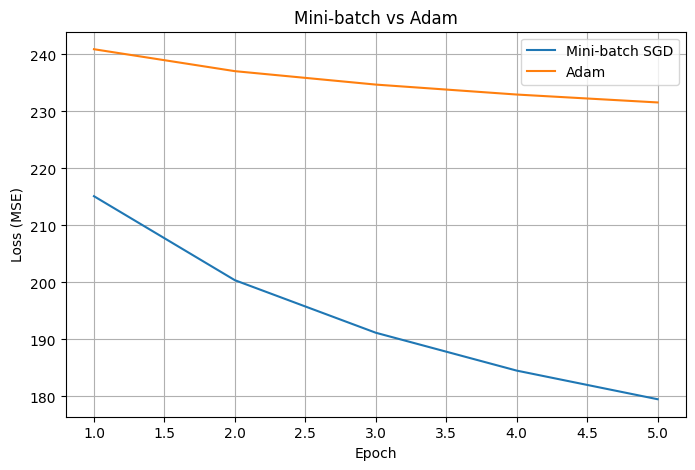

In [25]:
plt.figure(figsize=(8,5))
plt.plot(range(1,6), losses_mb, label='Mini-batch SGD')
plt.plot(range(1,6), losses_adam, label='Adam')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Mini-batch vs Adam')
plt.legend()
plt.grid(True)
#plt.savefig("minibatch_vs_adam.png", dpi=300, bbox_inches="tight")
plt.show()


## Exercice 3: Parcimonie et Algorithmes Proximaux

### Importation des données

In [26]:
from sklearn.datasets import fetch_rcv1
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from time import time

rcv1 = fetch_rcv1()

X = rcv1.data     
y = rcv1.target[:, 0].toarray().ravel()  # binary classification (classe 0)


n_samples = 5000
X = X[:n_samples]
y = y[:n_samples]

y = 2*y - 1  # {0,1} --> {-1, +1}

### b) ISTA

In [27]:
def soft_thresholding(v, lam):
    return np.sign(v) * np.maximum(np.abs(v) - lam, 0.0)


In [28]:
def lasso_loss(X, y, w, lam):
    residual = X @ w - y
    return 0.5 * np.mean(residual**2) + lam * np.sum(np.abs(w))


In [29]:
def ista(X, y, lam=0.01, lr=1e-3, n_iters=100):
    n_features = X.shape[1]
    w = np.zeros(n_features)
    losses = []

    for k in range(n_iters):
        grad = X.T @ (X @ w - y) / X.shape[0]
        w = soft_thresholding(w - lr * grad, lr * lam)

        loss = lasso_loss(X, y, w, lam)
        losses.append(loss)

    return w, losses


In [30]:
start = time()
w_ista, losses_ista = ista(X, y, lam=0.01, lr=1e-3, n_iters=100)
time_ista = time() - start

print(f"ISTA final loss: {losses_ista[-1]:.4f}")
print(f"ISTA time: {time_ista:.2f}s")
print(f"Nombre de coefficients non nuls: {np.sum(w_ista != 0)}")


ISTA final loss: 31443.1378
ISTA time: 0.46s
Nombre de coefficients non nuls: 15238


### c) Accélération

In [32]:
def fista(X, y, lam=0.01, lr=1e-3, n_iters=100):
    n_features = X.shape[1]
    w = np.zeros(n_features)
    z = w.copy()
    t = 1.0
    losses = []

    for k in range(n_iters):
        grad = X.T @ (X @ z - y) / X.shape[0]
        w_new = soft_thresholding(z - lr * grad, lr * lam)

        t_new = (1 + np.sqrt(1 + 4 * t**2)) / 2
        z = w_new + ((t - 1) / t_new) * (w_new - w)

        w, t = w_new, t_new

        loss = lasso_loss(X, y, w, lam)
        losses.append(loss)

    return w, losses


In [33]:
start = time()
w_fista, losses_fista = fista(X, y, lam=0.01, lr=1e-3, n_iters=100)
time_fista = time() - start

print(f"FISTA final loss: {losses_fista[-1]:.4f}")
print(f"FISTA time: {time_fista:.2f}s")
print(f"Nombre de coefficients non nuls: {np.sum(w_fista != 0)}")


FISTA final loss: 29989.4621
FISTA time: 0.52s
Nombre de coefficients non nuls: 15176


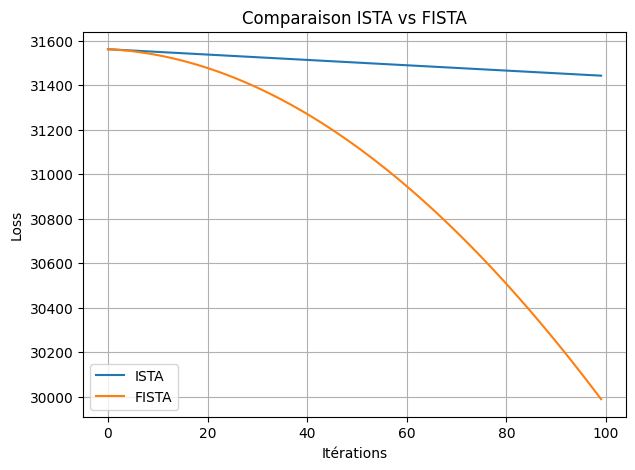

In [34]:
plt.figure(figsize=(7,5))
plt.plot(losses_ista, label="ISTA")
plt.plot(losses_fista, label="FISTA")
plt.xlabel("Itérations")
plt.ylabel("Loss")
plt.title("Comparaison ISTA vs FISTA")
plt.legend()
plt.grid(True)
#plt.savefig("ISTA_vs_FISTA.png", dpi=300)

plt.show()


### d) Sélection de variables

In [35]:
lambdas = [0.001, 0.01, 0.05, 0.1]
results = {}

for lam in lambdas:
    w, _ = fista(X, y, lam=lam, lr=1e-3, n_iters=100)
    nnz = np.sum(w != 0)
    results[lam] = w
    print(f"λ = {lam} | non-zero coefficients = {nnz}")


λ = 0.001 | non-zero coefficients = 21561
λ = 0.01 | non-zero coefficients = 15176
λ = 0.05 | non-zero coefficients = 5051
λ = 0.1 | non-zero coefficients = 3033
